# MBD Assignment 3 - Combined Notebook

## Task 1 Patterns

#### Part 1. Data Read and Preprocessing

This section loads the training and test datasets, processes the transaction dates, and constructs a unique transaction ID by combining Member_number and Date. Then, it groups items by transaction and applies one-hot encoding using TransactionEncoder to prepare the data for association rule mining (such as Apriori). The output is a binary matrix (df_encoded) where each row represents a transaction and each column represents whether an item was present in that transaction.

In [1]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

train_path = 'Groceries data train.csv'
test_path = 'Groceries data test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df['Date'] = pd.to_datetime(train_df['Date'], dayfirst=True)
test_df['Date'] = pd.to_datetime(test_df['Date'], dayfirst=True)

train_df['TransactionID'] = train_df['Member_number'].astype(str) + "_" + train_df['Date'].astype(str)
test_df['TransactionID'] = test_df['Member_number'].astype(str) + "_" + test_df['Date'].astype(str)

transactions = train_df.groupby('TransactionID')['itemDescription'].apply(list).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)



#### Part 2.  Exploratory Data Analysis

This section performs visual exploratory analysis on the training dataset to uncover patterns in item frequency and purchasing behavior:
- Top 20 Items Overall: Displays a bar chart of the 20 most frequently purchased items.
- Top 10 Item Pairs (Length = 2): Uses item combinations within transactions to identify the most frequently co-purchased item pairs.
- Monthly Transaction Trends: Shows the number of unique transactions each month to analyze temporal shopping behavior.
- Items per Transaction Distribution: Plots a histogram of how many items are typically bought per transaction to understand cart size trends.


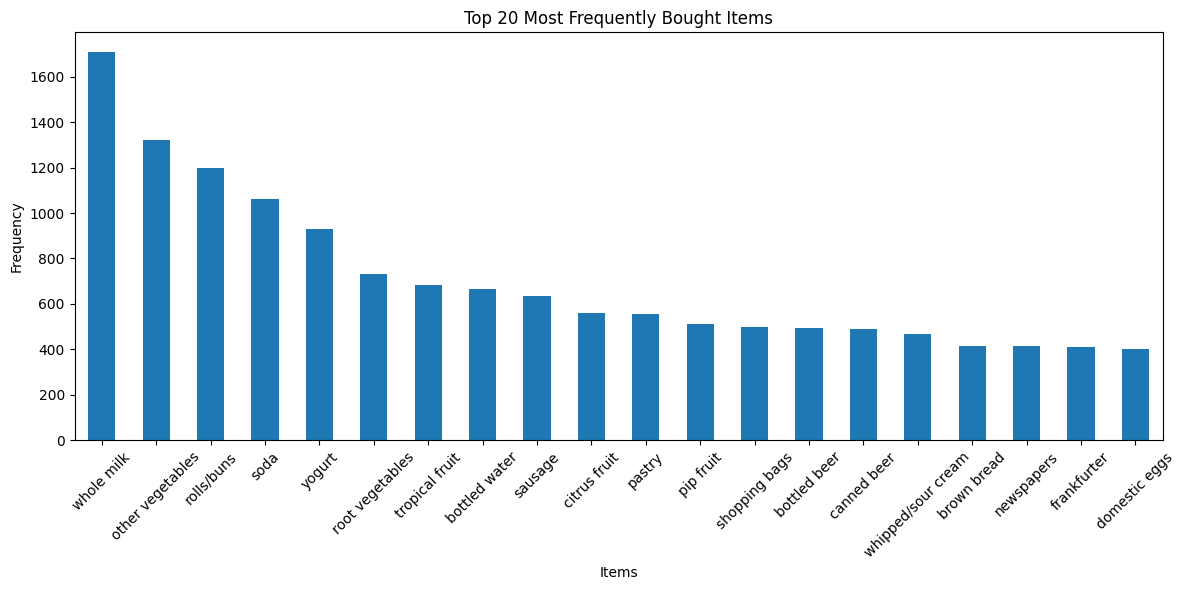

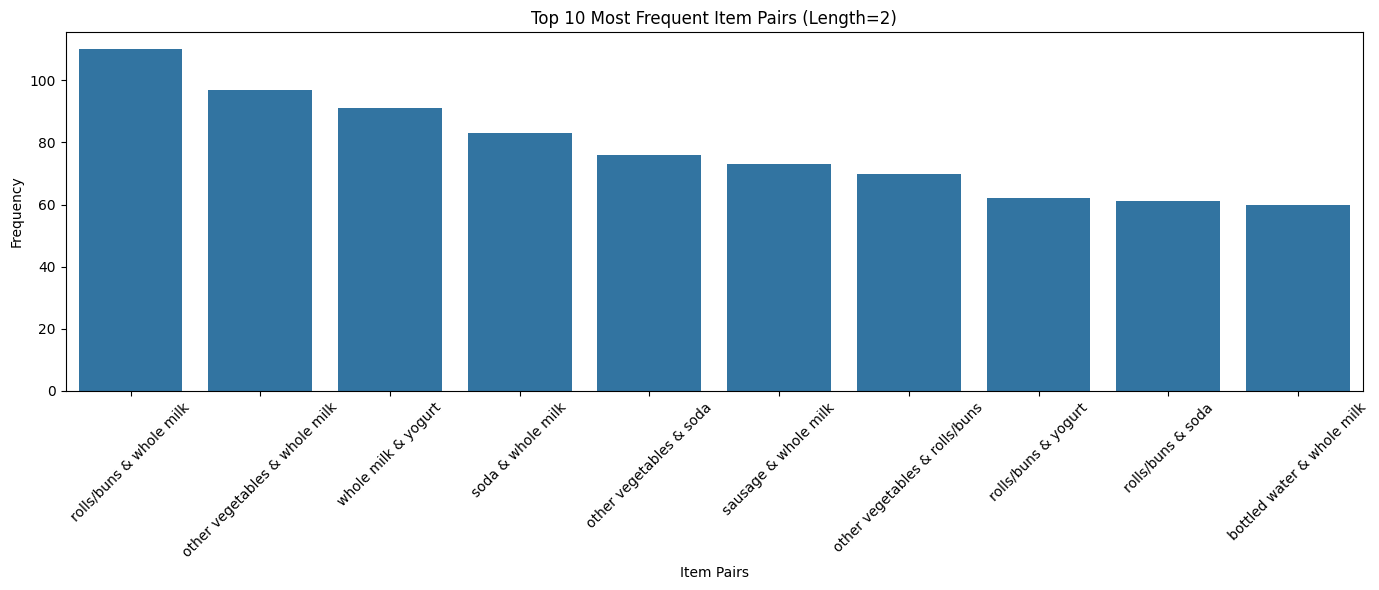

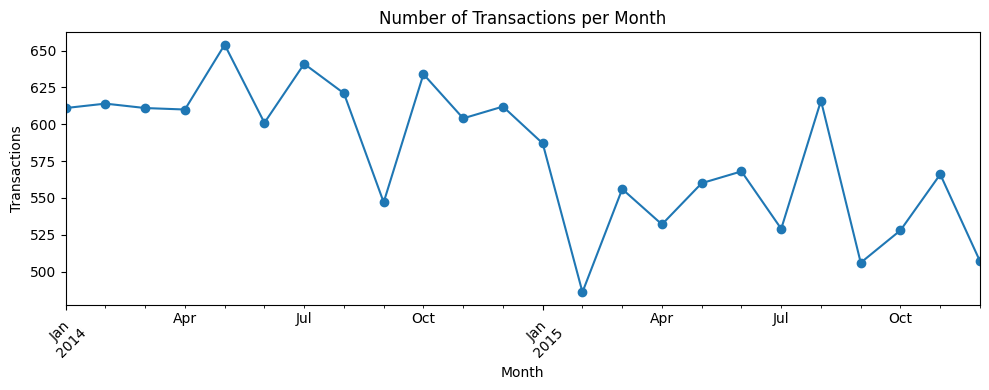

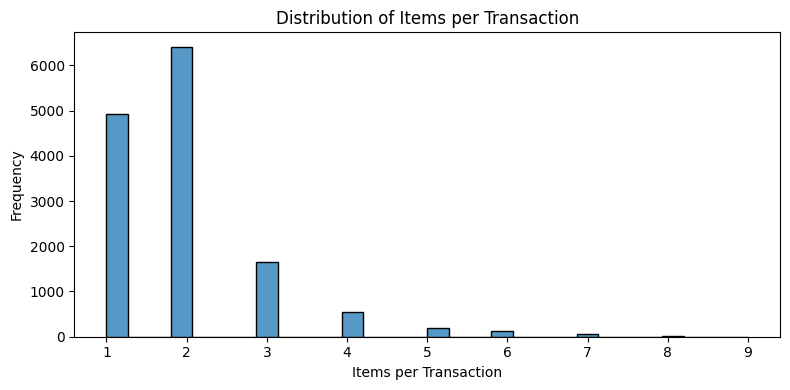

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 20 most frequent items
item_counts = train_df['itemDescription'].value_counts().head(20)
plt.figure(figsize=(12, 6))
item_counts.plot(kind='bar')
plt.title("Top 20 Most Frequently Bought Items")
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Most frequent items (length = 1)
top_items = train_df['itemDescription'].value_counts().head(10)

# Top item pairs (length = 2)
transaction_items = train_df.groupby('TransactionID')['itemDescription'].apply(set)

from collections import Counter
from itertools import combinations

pair_counter = Counter()
for items in transaction_items:
    if len(items) >= 2:
        for pair in combinations(sorted(items), 2):
            pair_counter[pair] += 1

top_pairs = pair_counter.most_common(10)
pair_labels, pair_counts = zip(*top_pairs)

# Transactions per month
train_df['Month'] = train_df['Date'].dt.to_period('M')
transactions_per_month = train_df.groupby('Month')['TransactionID'].nunique()

# Items per transaction
items_per_transaction = train_df.groupby(['Member_number', 'Date']).size()

# Top 10 Most Frequent Item Pairs (Length = 2)
plt.figure(figsize=(14, 6))
sns.barplot(x=[' & '.join(p) for p in pair_labels], y=pair_counts)
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Item Pairs (Length=2)')
plt.ylabel('Frequency')
plt.xlabel('Item Pairs')
plt.tight_layout()
plt.show()

# Monthly Transaction Trends
plt.figure(figsize=(10, 4))
transactions_per_month.plot(marker='o')
plt.title('Number of Transactions per Month')
plt.ylabel('Transactions')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Items per Transaction Distribution
plt.figure(figsize=(8, 4))
sns.histplot(items_per_transaction, bins=30, kde=False)
plt.title('Distribution of Items per Transaction')
plt.xlabel('Items per Transaction')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


#### Part 3: Frequent Pattern Discovery

The algorithm we use is Apriori algorithm. The Apriori algorithm is an algorithm used in association rule mining to identify frequent itemsets in databases. It works by the relationships between items in transactions to discover patterns, such as products which often bought together. Apriori filter out infrequent itemsets based on a support threshold that we have already defined. The main advantage of Apriori is its efficiency in pruning candidate itemsets, reducing computational complexity. It is widely used in market basket analysis, recommendation systems, and other applications that require discovering hidden patterns in large datasets.

Test the impact of the support threshold on the number of frequent itemsets. By changing the minimum support threshold, observe the number of frequent itemsets generated under different support thresholds. Also shows the  itemsets of different lengths

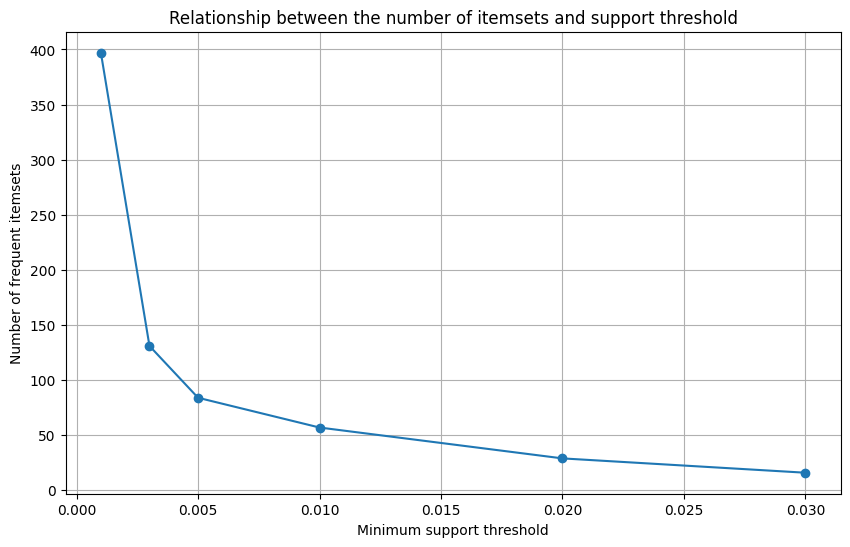

   min_support  total_itemsets  length_1  length_2
0        0.001             397       138     259.0
1        0.003             131       100      31.0
2        0.005              84        77       7.0
3        0.010              57        57       NaN
4        0.020              29        29       NaN
5        0.030              16        16       NaN


In [3]:
from mlxtend.frequent_patterns import apriori
import matplotlib.pyplot as plt
import pandas as pd

# testing different value of the support
min_support_values = [0.001, 0.003, 0.005, 0.01, 0.02, 0.03]
results = []

for min_sup in min_support_values:
    frequent_itemsets = apriori(df_encoded, min_support=min_sup, use_colnames=True)

    # Count the number of itemsets of different lengths
    length_counts = frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts().sort_index()

    # prepare the result
    result = {'min_support': min_sup, 'total_itemsets': len(frequent_itemsets)}
    for length, count in length_counts.items():
        result[f'length_{length}'] = count

    results.append(result)

# translate to DataFrame
threshold_comparison = pd.DataFrame(results)

# Visualize the number of itemsets at different thresholds
plt.figure(figsize=(10, 6))
plt.plot(threshold_comparison['min_support'], threshold_comparison['total_itemsets'], marker='o')
plt.title('Relationship between the number of itemsets and support threshold')
plt.xlabel('Minimum support threshold')
plt.ylabel('Number of frequent itemsets')
plt.grid(True)
plt.show()

# print the result
print(threshold_comparison)

#### Part 4: Top Frequent Length-2 Itemsets and Relative Support Calculation

This code identifies the most frequently occurring item pairs (itemsets of length = 2) from the transactional dataset using the Apriori algorithm, and then calculates how much each of the top 10 pairs contributes to the total support of all frequent pairs.

In [4]:
# Support: proportion of transactions in the entire dataset that contain this itemset.
# Length2_proportion: proportion of this itemset's support relative to the total support of all length-2 itemsets.
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_encoded, min_support=0.005, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

frequent_itemsets_sorted = frequent_itemsets.sort_values(by='support', ascending=False)

frequent_itemsets_len2 = frequent_itemsets_sorted[frequent_itemsets_sorted['length'] == 2].copy()

top10_len2 = frequent_itemsets_len2.head(10).copy()

total_len2_support = frequent_itemsets_len2['support'].sum()
top10_len2['Length2_proportion'] = top10_len2['support'] / total_len2_support

print(top10_len2[['itemsets', 'support', 'Length2_proportion']])

# Save frequent itemsets to CSV for Task 2
frequent_itemsets.to_csv("frequent_itemsets.csv", index=False)


                          itemsets   support  Length2_proportion
80        (rolls/buns, whole milk)  0.007913            0.183333
79  (other vegetables, whole milk)  0.006978            0.161667
83            (whole milk, yogurt)  0.006546            0.151667
82              (whole milk, soda)  0.005971            0.138333
78        (other vegetables, soda)  0.005467            0.126667
81           (whole milk, sausage)  0.005251            0.121667
77  (rolls/buns, other vegetables)  0.005036            0.116667


#### Part 5: Item Co-Occurrence Visualization

Shows each of the top 10 most frequently purchased items was purchased together with other items in the same transaction. It's classified as non-personalized recommendations

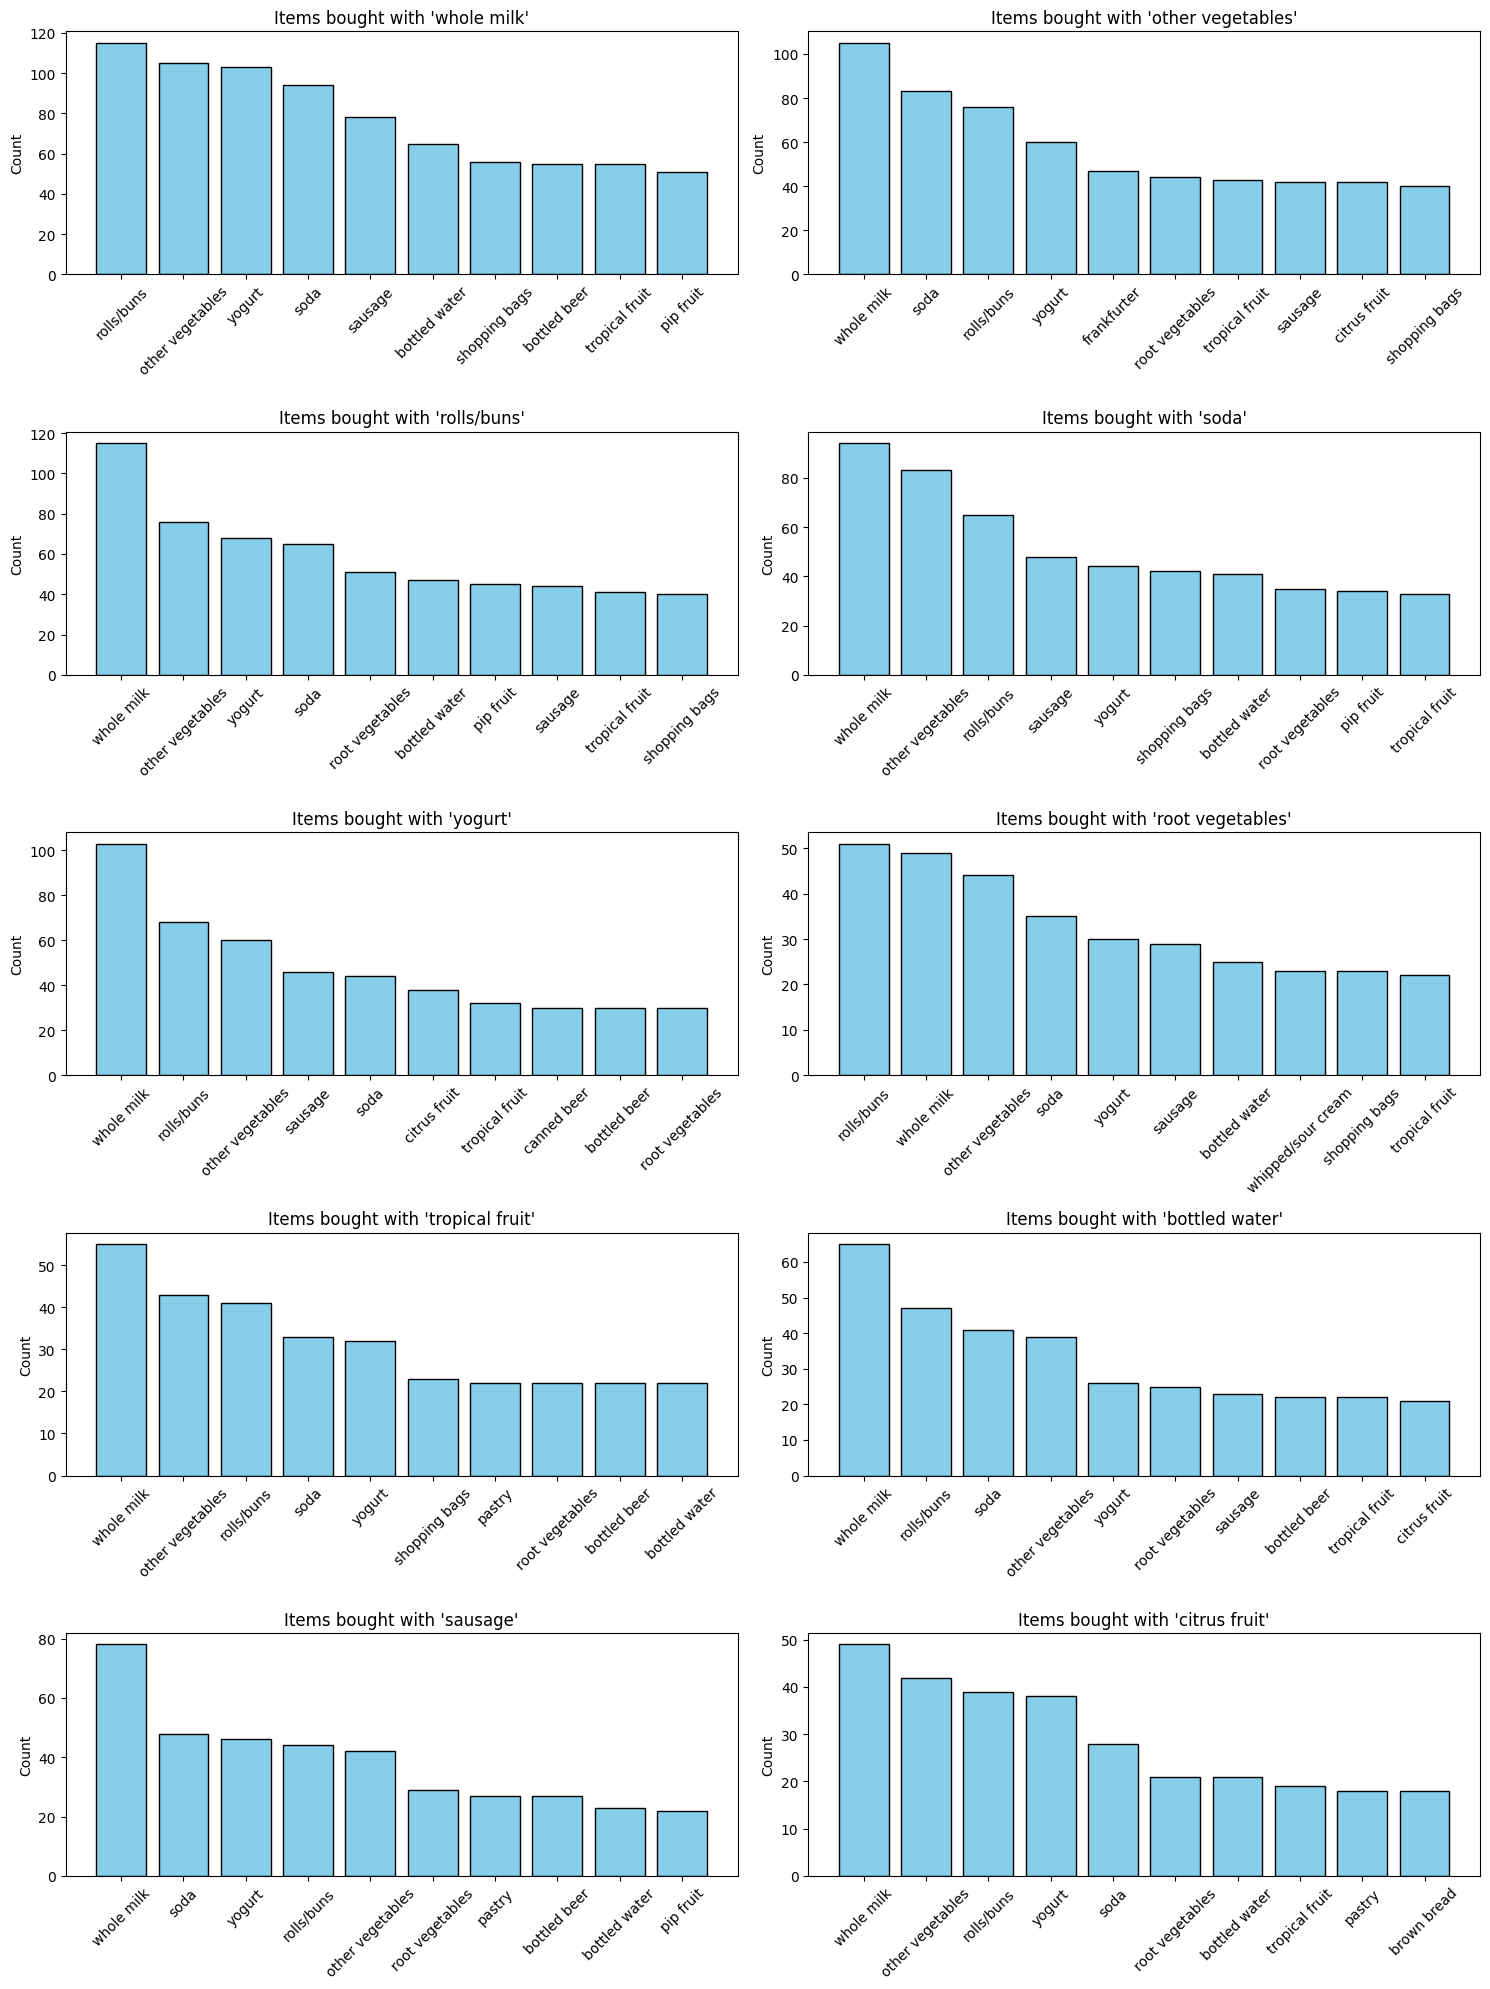

In [5]:
import json

top_10_items = train_df['itemDescription'].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

co_occurrence_dict = {}

for idx, item in enumerate(top_10_items):
    item_transactions = train_df[train_df['itemDescription'] == item][['Member_number', 'Date']]
    merged = pd.merge(item_transactions, train_df, on=['Member_number', 'Date'])

    co_items = merged[merged['itemDescription'] != item]['itemDescription'].value_counts().head(10)
    co_occurrence_dict[item] = co_items.index.tolist()
    
    axes[idx].bar(co_items.index, co_items.values, color='skyblue', edgecolor='black')
    axes[idx].set_title(f"Items bought with '{item}'")
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylabel("Count")

plt.tight_layout()
plt.show()


# Save as JSON to load in Task 2

with open("co_occurrence_dict.json", "w") as f:
    json.dump(co_occurrence_dict, f)


### Part 6: Top Members’ Frequent Item Analysis in Length-2 Transactions

This part analyzes shopping patterns focusing on transactions with exactly two items (length-2 transactions) and identifies the most frequent item pairs purchased by the top customers.
First, Understanding which products are commonly purchased together by high-frequency customers. And enabling personalized promotions based on customers' preferred product pairs. It shows that Revealing patterns in the purchasing behavior of the most active customers.

In [6]:
from itertools import combinations

transaction_counts = train_df.groupby(['Member_number', 'Date'])['itemDescription'].count()
length_2_indices = transaction_counts[transaction_counts == 2].index
length_2_df = train_df.set_index(['Member_number', 'Date']).loc[length_2_indices].reset_index()

length_2_baskets = length_2_df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)
top_10_members = length_2_baskets.index.get_level_values(0).value_counts().head(10).index

results = []

for member in top_10_members:
    member_baskets = length_2_baskets[length_2_baskets.index.get_level_values(0) == member]

    pairs = member_baskets.apply(lambda x: tuple(sorted(x)))

    pair_counts = pairs.value_counts().head(3)

    top_pairs = list(pair_counts.index)
    counts = list(pair_counts.values)

    while len(top_pairs) < 3:
        top_pairs.append((None, None))
        counts.append(None)

    results.append([
        member,
        len(member_baskets),
        top_pairs[0], counts[0],
        top_pairs[1], counts[1],
        top_pairs[2], counts[2]
    ])

columns = [
    'Member_number', 'Total_Length_2_Purchases',
    'Top_Pair_1', 'Top_Pair_1_Count',
    'Top_Pair_2', 'Top_Pair_2_Count',
    'Top_Pair_3', 'Top_Pair_3_Count'
]

top_pairs_df = pd.DataFrame(results, columns=columns)

print("Top 10 Members and Their Most Frequent Item Pairs in Length-2 Transactions:\n")
print(top_pairs_df)

# Decide not use for the next tasks.

Top 10 Members and Their Most Frequent Item Pairs in Length-2 Transactions:

   Member_number  Total_Length_2_Purchases  \
0           1379                         8   
1           4656                         8   
2           4695                         7   
3           2193                         7   
4           2406                         7   
5           4262                         6   
6           4512                         6   
7           4623                         6   
8           4187                         6   
9           4206                         6   

                            Top_Pair_1  Top_Pair_1_Count  \
0  (fruit/vegetable juice, photo/film)                 1   
1                (hamburger meat, oil)                 1   
2                    (beverages, pork)                 1   
3           (bottled beer, whole milk)                 1   
4                     (butter, yogurt)                 1   
5             (domestic eggs, napkins)                 1

Reference: Workshop Week 9

## Task 2 Collaborative Filtering

#### Part 1: Data Preprocessing

In [7]:
import pandas as pd
import numpy as np
from math import log2

# Data loading and preprocessing
train_path = 'Groceries data train.csv'
test_path = 'Groceries data test.csv'


train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df['Date'] = pd.to_datetime(train_df['Date'], dayfirst=True)
test_df['Date'] = pd.to_datetime(test_df['Date'], dayfirst=True)



#### Part 2: User-Based Collaborative Filtering Recommendation

This code implements a user-based collaborative filtering recommendation system. It begins by constructing a binary user-item matrix that indicates whether each user has purchased specific items. Using this matrix, it computes cosine similarity scores between users to quantify how similar their purchase behaviors are. For each test user, the algorithm identifies the top-k most similar users and aggregates the items they have bought. It then filters out items already purchased by the test user and selects the top-n most common remaining items as recommendations. The results are compiled into a DataFrame that maps each user to their recommended items

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# Build binary user-item matrix
user_item_matrix = train_df.groupby(['Member_number', 'itemDescription']).size().unstack(fill_value=0)
user_item_matrix = (user_item_matrix > 0).astype(int)

# Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# Define recommendation function
def recommend_items_for_user(user_id, top_k_users=5, top_n_items=3):
    if user_id not in user_item_matrix.index:
        return []
    
    similar_users = user_similarity_df.loc[user_id].drop(user_id).sort_values(ascending=False).head(top_k_users).index
    similar_user_items = user_item_matrix.loc[similar_users].sum(axis=0)
    already_bought = user_item_matrix.loc[user_id]
    recommendations = similar_user_items[already_bought == 0].sort_values(ascending=False).head(top_n_items)
    return list(recommendations.index)

# Recommend for all test users
test_users = test_df['Member_number'].unique()
recommendation_results = []

for user in test_users:
    if user in user_item_matrix.index:
        recs = recommend_items_for_user(user)
        recommendation_results.append({'Member_number': user, 'Recommended_Items': recs})

recommendation_df = pd.DataFrame(recommendation_results)
recommendation_df.head(10)


,Member_number,Recommended_Items
0,3481,"[semi-finished bread, soft cheese, whipped/sou..."
1,1254,"[canned beer, whole milk, white wine]"
2,2835,"[berries, root vegetables, butter]"
3,2854,"[whipped/sour cream, pork, frozen vegetables]"
4,4637,"[tropical fruit, meat, Instant food products]"
5,1547,"[curd, popcorn, berries]"
6,2613,"[pork, bottled beer, fruit/vegetable juice]"
7,2051,"[sausage, shopping bags, tropical fruit]"
8,2736,"[butter, citrus fruit, fruit/vegetable juice]"
9,4747,"[yogurt, canned vegetables, bottled beer]"


#### Part 2-1: Cosine similarity recommendation system Evaluation

This code evaluates the cosine similarity recommendation system using three metrics. It calculates coverage as the proportion of users who received recommendations, computes the average number of items recommended per user, and assesses item novelty by penalizing popular items using a negative log2 of their frequency in the training dataset.

In [9]:
# Coverage
num_users_with_recs = sum(1 for r in recommendation_results if len(r['Recommended_Items']) > 0)
total_users = len(recommendation_results)
coverage = num_users_with_recs / total_users
print(f"Coverage: {coverage:.4f}")

# Average Recommendation Length
avg_recommendation_length = np.mean([len(r['Recommended_Items']) for r in recommendation_results])
print(f"Avg Recommendation Length: {avg_recommendation_length:.4f}")

# Average Item Novelty
item_counts = train_df['itemDescription'].value_counts()
total_interactions = item_counts.sum()
item_prob = item_counts / total_interactions
item_novelty = {item: -log2(prob) for item, prob in item_prob.items()}

all_recommended_items = [item for r in recommendation_results for item in r['Recommended_Items']]
novelty_scores = [item_novelty.get(item, 0) for item in all_recommended_items]
avg_item_novelty = np.mean(novelty_scores)
print(f"Avg Item Novelty: {avg_item_novelty:.4f}")


Coverage: 1.0000
Avg Recommendation Length: 3.0000
Avg Item Novelty: 6.4765


#### Part 3: Model-Based Collaborative Filtering using SVD

This section implements model-based collaborative filtering using UV decomposition (Truncated SVD). It factorizes the user-item interaction matrix into latent user and item factors, reconstructs the predicted rating matrix, and generates top-N item recommendations for each user by excluding previously purchased items.

In [10]:
from sklearn.decomposition import TruncatedSVD

user_item_matrix_filled = user_item_matrix.fillna(0)

svd = TruncatedSVD(n_components=20, random_state=42)
U = svd.fit_transform(user_item_matrix_filled)
V = svd.components_

R_hat = np.dot(U, V)
R_hat_df = pd.DataFrame(R_hat, index=user_item_matrix.index, columns=user_item_matrix.columns)

def get_top_k_svd_recommendations(user_id, R_hat_df, user_item_matrix, k=3):
    if user_id not in R_hat_df.index:
        return []
    bought = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist()
    preds = R_hat_df.loc[user_id].sort_values(ascending=False)
    recommendations = [item for item in preds.index if item not in bought][:k]
    return recommendations

test_users = test_df['Member_number'].unique()
svd_recommendations = []

for user in test_users:
    recs = get_top_k_svd_recommendations(user, R_hat_df, user_item_matrix)
    svd_recommendations.append({'Member_number': user, 'SVD_Recommendations': recs})

svd_df = pd.DataFrame(svd_recommendations)
print(svd_df.head())


   Member_number                           SVD_Recommendations
0           3481  [butter, fruit/vegetable juice, brown bread]
1           1254             [citrus fruit, frankfurter, soda]
2           2835              [domestic eggs, butter, chicken]
3           2854           [frankfurter, pork, hamburger meat]
4           4637            [curd, white bread, domestic eggs]


#### Part 3-1: SVD model Evaluation

This code evaluates the SVD-based recommender system using three metrics. It calculates coverage by measuring how many users received at least one recommendation, computes the average number of items recommended per user, and assesses item novelty by penalizing popular items using a negative log2 transformation of item frequency from the training dataset.

In [11]:
# Coverage
num_users_with_recs = sum(1 for r in svd_recommendations if len(r['SVD_Recommendations']) > 0)
total_users = len(svd_recommendations)
coverage = num_users_with_recs / total_users
print(f"Coverage: {coverage:.4f}")

# Average Recommendation Length
avg_recommendation_length = np.mean([len(r['SVD_Recommendations']) for r in svd_recommendations])
print(f"Avg Recommendation Length: {avg_recommendation_length:.4f}")

# Average Item Novelty
item_counts = train_df['itemDescription'].value_counts()
total_interactions = item_counts.sum()
item_prob = item_counts / total_interactions
item_novelty = {item: -log2(prob) for item, prob in item_prob.items()}

all_recommended_items = [item for r in svd_recommendations for item in r['SVD_Recommendations']]
novelty_scores = [item_novelty.get(item, 0) for item in all_recommended_items]
avg_item_novelty = np.mean(novelty_scores)
print(f"Avg Item Novelty: {avg_item_novelty:.4f}")


Coverage: 0.9927
Avg Recommendation Length: 2.9781
Avg Item Novelty: 6.2574


#### Part 4: Pattern-Based Recommendation from Task 1 Frequent Itemsets

We make a recommender systems based on frequent itemset patterns. It recommends items that users may be interested in by analyzing their purchase history and the combinations of items that are frequently purchased together. If no suitable recommendations are found, the system falls back to the list of most frequently purchased items.

In [12]:
frequent_itemsets_path = "frequent_itemsets.csv"
frequent_itemsets = pd.read_csv(frequent_itemsets_path)

frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(eval)
top_10_items = train_df['itemDescription'].value_counts().head(10).index.tolist()

train_df_path = "Groceries data train.csv"
train_df = pd.read_csv(train_df_path)
train_df['Date'] = pd.to_datetime(train_df['Date'], dayfirst=True)

user_item_matrix = train_df.groupby(['Member_number', 'itemDescription']).size().unstack(fill_value=0)
user_item_matrix = (user_item_matrix > 0).astype(int)

def recommend_from_patterns(user_id, frequent_itemsets_df, top_n=3):
    if user_id not in user_item_matrix.index:
        return top_10_items[:top_n]  # fallback for new users
    
    bought = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)
    candidate_items = []

    for _, row in frequent_itemsets_df.iterrows():
        itemset = set(row['itemsets'])
        if itemset & bought:
            new_items = itemset - bought
            candidate_items.extend(new_items)

    if not candidate_items:
        return top_10_items[:top_n]  # fallback if no matching patterns

    recommended = pd.Series(candidate_items).value_counts().head(top_n).index.tolist()
    return recommended


# Test
test_df_path = "Groceries data test.csv"
test_df = pd.read_csv(test_df_path)
test_df['Date'] = pd.to_datetime(test_df['Date'], dayfirst=True)

test_users = test_df['Member_number'].unique()

pattern_recommendations = []

for user in test_users:
    recs = recommend_from_patterns(user, frequent_itemsets)
    pattern_recommendations.append({'Member_number': user, 'Pattern_Recommended_Items': recs})

pattern_recommendation_df = pd.DataFrame(pattern_recommendations)

print(pattern_recommendation_df.head(10))



   Member_number                   Pattern_Recommended_Items
0           3481                       [rolls/buns, sausage]
1           1254  [whole milk, other vegetables, rolls/buns]
2           2835           [other vegetables, sausage, soda]
3           2854                     [soda, sausage, yogurt]
4           4637              [other vegetables, whole milk]
5           1547     [other vegetables, rolls/buns, sausage]
6           2613                                [whole milk]
7           2051                     [soda, sausage, yogurt]
8           2736     [other vegetables, rolls/buns, sausage]
9           4747              [rolls/buns, soda, whole milk]


#### Part 4-1: Pattern-based Recommendation Evaluation

This code evaluates the pattern-based recommender using three metrics. It measures coverage as the percentage of users who received at least one recommendation, computes the average number of recommended items per user, and calculates novelty using the negative log2 of item popularity from training data to favor less frequent and more diverse suggestions

In [13]:
# Coverage
num_users_with_recs = sum(1 for r in pattern_recommendations if len(r['Pattern_Recommended_Items']) > 0)
total_users = len(pattern_recommendations)
coverage = num_users_with_recs / total_users
print(f"Coverage: {coverage:.4f}")

# Average Recommendation Length
avg_recommendation_length = np.mean([len(r['Pattern_Recommended_Items']) for r in pattern_recommendations])
print(f"Avg Recommendation Length: {avg_recommendation_length:.4f}")

# Average Item Novelty
item_counts = train_df['itemDescription'].value_counts()
total_interactions = item_counts.sum()
item_prob = item_counts / total_interactions
item_novelty = {item: -log2(prob) for item, prob in item_prob.items()}

all_recommended_items = [item for r in pattern_recommendations for item in r['Pattern_Recommended_Items']]
novelty_scores = [item_novelty.get(item, 0) for item in all_recommended_items]
avg_item_novelty = np.mean(novelty_scores)
print(f"Avg Item Novelty: {avg_item_novelty:.4f}")


Coverage: 1.0000
Avg Recommendation Length: 2.5236
Avg Item Novelty: 4.4641


#### Part 5: Co-Occurrence Based Recommendation

By analyzing the co-occurrence relationship between each product and other products, the system recommends other products related to the ones the user has already purchased. If no suitable recommendations are found, the system will fallback to the most frequently purchased item list.

In [14]:
import json

with open("co_occurrence_dict.json", "r") as f:
    co_occurrence_dict = json.load(f)

co_occurrence_recommendations = []

for user in test_users:
    if user not in user_item_matrix.index:
        recs = top_10_items[:3]
    else:
        bought = user_item_matrix.loc[user][user_item_matrix.loc[user] > 0].index.tolist()
        rec_scores = {}

        for item in bought:
            if item in co_occurrence_dict:
                for rec_item in co_occurrence_dict[item]:
                    if rec_item not in bought:
                        rec_scores[rec_item] = rec_scores.get(rec_item, 0) + 1
        
        # Sort recommendations by their co-occurrence frequency
        sorted_recs = sorted(rec_scores, key=rec_scores.get, reverse=True)[:3]

        # Fallback to global top items if no recommendations
        recs = sorted_recs if sorted_recs else top_10_items[:3]

    co_occurrence_recommendations.append({
        'Member_number': user,
        'CoOccurrence_Recommendations': recs
    })

co_occurrence_df = pd.DataFrame(co_occurrence_recommendations)
print(co_occurrence_df.head(10))


   Member_number                   CoOccurrence_Recommendations
0           3481          [rolls/buns, tropical fruit, sausage]
1           1254     [whole milk, other vegetables, rolls/buns]
2           2835              [other vegetables, soda, sausage]
3           2854                 [soda, yogurt, tropical fruit]
4           4637         [whole milk, other vegetables, yogurt]
5           1547        [other vegetables, rolls/buns, sausage]
6           2613  [whole milk, root vegetables, tropical fruit]
7           2051                 [soda, yogurt, tropical fruit]
8           2736         [other vegetables, rolls/buns, yogurt]
9           4747                 [whole milk, soda, rolls/buns]


#### Part 5-1: Co-occurance Model Evaluation

This code evaluates the co-occurrence-based recommendation system using three metrics. It calculates coverage to determine how many users received suggestions, computes the average number of items recommended per user, and estimates novelty by penalizing popular items using negative log2 probability. These metrics reflect the model’s reach, consistency, and diversity.

In [15]:
# Coverage
num_users_with_recs = sum(1 for r in co_occurrence_recommendations if len(r['CoOccurrence_Recommendations']) > 0)
total_users = len(co_occurrence_recommendations)
coverage = num_users_with_recs / total_users
print(f"Coverage: {coverage:.4f}")

# Average Recommendation Length
avg_recommendation_length = np.mean([len(r['CoOccurrence_Recommendations']) for r in co_occurrence_recommendations])
print(f"Avg Recommendation Length: {avg_recommendation_length:.4f}")

# Average Item Novelty
item_counts = train_df['itemDescription'].value_counts()
total_interactions = item_counts.sum()
item_prob = item_counts / total_interactions
item_novelty = {item: -log2(prob) for item, prob in item_prob.items()}

all_recommended_items = [item for r in co_occurrence_recommendations for item in r['CoOccurrence_Recommendations']]
novelty_scores = [item_novelty.get(item, 0) for item in all_recommended_items]
avg_item_novelty = np.mean(novelty_scores)
print(f"Avg Item Novelty: {avg_item_novelty:.4f}")


Coverage: 1.0000
Avg Recommendation Length: 3.0000
Avg Item Novelty: 4.4833


In [16]:
# Save the output to use in Task 3
user_item_matrix.to_csv("user_item_matrix.csv")

user_similarity_df.to_csv("user_similarity.csv")


Reference: Workshop Week 10

## Task 3

##### Part 1: Using Stub Method (Dummy Code)

#### Part 1-1: Simulated Output from Task 1 and Task 2

This section provides mock data for testing Task 3 independently. stub_task1() simulates frequent patterns and co-occurrence logic. stub_task2() returns outputs from two collaborative filtering models: a cosine similarity-based CF and a UV decomposition model. These outputs simulate the real recommendations generated in Task 2.

In [17]:
import numpy as np
from math import log2

def stub_task1():
    """
    Simulated Task 1 combining:
    - Top frequent individual items
    - Top frequent co-occurring item pairs
    """
    top_frequent_items = ['whole milk', 'other vegetables', 'rolls/buns', 'yogurt', 'soda']

    co_occurrence_dict = {
        'rolls/buns': ['whole milk', 'other vegetables'],
        'whole milk': ['rolls/buns', 'other vegetables', 'yogurt', 'soda', 'sausage'],
        'other vegetables': ['whole milk', 'soda', 'rolls/buns'],
        'yogurt': ['whole milk'],
        'soda': ['whole milk', 'other vegetables'],
        'sausage': ['whole milk']
    }

    return top_frequent_items, co_occurrence_dict

def stub_task2():
    return {
        "cf_model_1": {
            'user1': ['whole milk', 'rolls/buns', 'yogurt'],
            'user2': ['other vegetables', 'sausage', 'whole milk'],
            'user3': ['tropical fruit', 'yogurt', 'butter']
        },
        "cf_model_2": {
            'user1': ['yogurt', 'whole milk', 'soda'],
            'user2': ['rolls/buns', 'soda', 'other vegetables'],
            'user3': ['whole milk', 'butter', 'sausage']
        }
    }


#### Part 1-2: Hybrid Recommendation Function

This function combines multiple signals to generate a final recommendation list. It assigns weights to items from CF model 1 (+1.0), CF model 2 (+0.8), and boosts co-occurring items (+0.5) based on Task 1. It also adds fallback scores for globally frequent items (+0.1). The final list is sorted by total score.

In [18]:
def hybrid_recommendation(user_id, top_items, co_dict, cf_dict_1, cf_dict_2, top_n=3):
    scores = {}

    for item in cf_dict_1.get(user_id, []):
        scores[item] = scores.get(item, 0) + 1.0

    for item in cf_dict_2.get(user_id, []):
        scores[item] = scores.get(item, 0) + 0.8  

    for item in cf_dict_1.get(user_id, []) + cf_dict_2.get(user_id, []):
        if item in co_dict:
            for co_item in co_dict[item]:
                scores[co_item] = scores.get(co_item, 0) + 0.5

    for item in top_items:
        scores[item] = scores.get(item, 0) + 0.1

    sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [item for item, _ in sorted_items[:top_n]]


#### Part 1-3: Execution and Output 

This part calls the stub methods to simulate Task 1 and Task 2 outputs, unpacks the values, defines test users, and runs the hybrid_recommendation() function for each user. It prints the top recommended items by combining collaborative filtering and frequent pattern signalsto meet the goal of Task 3.

In [19]:
task1_output = stub_task1()
task2_output = stub_task2()

top_items, co_dict = task1_output
cf_dict_1 = task2_output["cf_model_1"]
cf_dict_2 = task2_output["cf_model_2"]

test_users = ['user1', 'user2', 'user3']

for user in test_users:
    recs = hybrid_recommendation(user, top_items, co_dict, cf_dict_1, cf_dict_2)
    print(f"Hybrid recommendations for {user}: {recs}")


Hybrid recommendations for user1: ['whole milk', 'yogurt', 'rolls/buns']
Hybrid recommendations for user2: ['whole milk', 'other vegetables', 'rolls/buns']
Hybrid recommendations for user3: ['whole milk', 'butter', 'yogurt']


##### Part 2: Using Real Output from Task 1 and Task 2

#### Part 2-1: Load Actual Outputs from Task 1 and Task 2

This section loads the real outputs from Task 1 and Task 2 to support hybrid recommendations in Task 3. It imports the frequent itemsets and co-occurrence dictionary from Task 1, loads and preprocesses the training data, and builds the user-item interaction matrix. Then, it calculates cosine similarity to create user_similarity_df, enabling collaborative filtering based on user similarity for generating personalized recommendations.

In [20]:
import pandas as pd
import json
from sklearn.metrics.pairwise import cosine_similarity

frequent_itemsets_path = "frequent_itemsets.csv"
frequent_itemsets_df = pd.read_csv(frequent_itemsets_path)
frequent_itemsets_df['itemsets'] = frequent_itemsets_df['itemsets'].apply(eval)
with open("co_occurrence_dict.json", "r") as f:
    co_occurrence_dict = json.load(f)

train_df = pd.read_csv("Groceries data train.csv")
train_df['Date'] = pd.to_datetime(train_df['Date'], dayfirst=True)

user_item_matrix = train_df.groupby(['Member_number', 'itemDescription']).size().unstack(fill_value=0)
user_item_matrix = (user_item_matrix > 0).astype(int)

user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)


#### Part 2-2: Hybrid Recommendation

This section implements an enhanced hybrid recommendation system that significantly improves upon basic collaborative filtering approaches. The system combines multiple advanced techniques:

**1. Temporal User Profiling**: Builds comprehensive user profiles considering both purchase frequency and recency using exponential decay weighting (30-day decay factor) to prioritize recent purchases while maintaining historical preferences.

**2. Enhanced Collaborative Filtering**: Implements weighted similarity calculations that account for user profile diversity strength. Users with more varied purchase histories receive higher similarity weights, and each recommendation includes confidence scoring based on similarity strength and item frequency.

**3. Intelligent Pattern-Based Recommendations**: Leverages frequent itemsets with support-weighted scoring. The system calculates user affinity for pattern items based on purchase history and considers pattern coverage (percentage of pattern already purchased by user).

**4. Smart Fallback Mechanism**: Instead of simple popularity-based recommendations, implements diversity-aware fallback that excludes already recommended and purchased items while providing normalized popularity scores.

**5. Advanced Hybrid Scoring**: Uses sophisticated weighted combination with differentiated contributions: collaborative filtering (2.0x weight), pattern-based recommendations (1.5x weight), and fallback suggestions (0.3x weight). This ensures optimal balance between personalization and diversity.

Note: This part will run for around 15 minutes


In [21]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from collections import defaultdict

# Build user profiles based on purchase frequency and recency
def build_user_profiles(train_df):
    user_profiles = {}
    train_df['Date'] = pd.to_datetime(train_df['Date'])
    latest_date = train_df['Date'].max()
    
    for user in train_df['Member_number'].unique():
        user_data = train_df[train_df['Member_number'] == user]
        
        # Calculate item frequencies for this user
        item_freq = user_data['itemDescription'].value_counts()
        
        # Calculate recency weights (more recent purchases get higher weights)
        user_data_with_days = user_data.copy()
        user_data_with_days['days_ago'] = (latest_date - user_data_with_days['Date']).dt.days
        recency_weights = np.exp(-user_data_with_days['days_ago'] / 30)  # 30-day decay
        
        # Combine frequency and recency
        item_scores = defaultdict(float)
        for idx, row in user_data_with_days.iterrows():
            item = row['itemDescription']
            recency_weight = np.exp(-row['days_ago'] / 30)
            item_scores[item] += recency_weight
        
        user_profiles[user] = dict(item_scores)
    
    return user_profiles

# Enhanced collaborative filtering with weighted similarity
def cf_recommendation(user_id, user_item_matrix, user_profiles, top_k_users=10, top_n_items=5):
    if user_id not in user_item_matrix.index:
        return [], []
    
    # Calculate weighted cosine similarity based on user profiles
    user_vector = user_item_matrix.loc[user_id]
    similarities = []
    
    for other_user in user_item_matrix.index:
        if other_user == user_id:
            continue
            
        other_vector = user_item_matrix.loc[other_user]
        
        # Weight by user profile strength (users with more diverse purchases get higher weight)
        user_strength = len(user_profiles.get(user_id, {}))
        other_strength = len(user_profiles.get(other_user, {}))
        strength_weight = min(user_strength, other_strength) / max(user_strength, other_strength, 1)
        
        # Calculate cosine similarity
        dot_product = np.dot(user_vector, other_vector)
        norm_product = np.linalg.norm(user_vector) * np.linalg.norm(other_vector)
        
        if norm_product > 0:
            similarity = (dot_product / norm_product) * strength_weight
            similarities.append((other_user, similarity))
    
    # Get top similar users
    similarities.sort(key=lambda x: x[1], reverse=True)
    top_similar_users = [user for user, _ in similarities[:top_k_users]]
    
    # Aggregate recommendations with confidence scores
    item_scores = defaultdict(float)
    item_confidence = defaultdict(float)
    
    for similar_user in top_similar_users:
        similarity_score = dict(similarities)[similar_user]
        user_items = user_item_matrix.loc[similar_user]
        
        for item in user_items[user_items > 0].index:
            if user_vector[item] == 0:  # User hasn't bought this item
                # Weight by similarity and user's preference for this item
                item_freq = user_profiles.get(similar_user, {}).get(item, 1)
                item_scores[item] += similarity_score * item_freq
                item_confidence[item] += similarity_score
    
    # Sort by score and return top items with confidence
    sorted_items = sorted(item_scores.items(), key=lambda x: x[1], reverse=True)
    recommended_items = [item for item, _ in sorted_items[:top_n_items]]
    confidence_scores = [item_confidence[item] for item in recommended_items]
    
    return recommended_items, confidence_scores

# Enhanced pattern-based recommendation with support weighting
def pattern_recommendation(user_id, frequent_itemsets_df, user_item_matrix, user_profiles, top_n=5):
    if user_id not in user_item_matrix.index:
        return [], []
    
    bought_items = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)
    user_preferences = user_profiles.get(user_id, {})
    
    item_scores = defaultdict(float)
    
    # Sort itemsets by support (more frequent patterns get higher priority)
    sorted_itemsets = frequent_itemsets_df.sort_values('support', ascending=False)
    
    for _, row in sorted_itemsets.iterrows():
        itemset = set(row['itemsets'])
        support = row['support']
        
        # Check if user bought any items in this pattern
        intersection = itemset & bought_items
        if intersection:
            # Calculate user's affinity for the bought items in this pattern
            affinity_score = sum(user_preferences.get(item, 1) for item in intersection) / len(intersection)
            
            # Recommend unburied items from this pattern
            recommended_items = itemset - bought_items
            for item in recommended_items:
                # Score based on pattern support, user affinity, and pattern coverage
                pattern_strength = len(intersection) / len(itemset)  # How much of pattern user already bought
                item_scores[item] += support * affinity_score * pattern_strength
    
    # Sort and return top items with scores
    sorted_items = sorted(item_scores.items(), key=lambda x: x[1], reverse=True)
    recommended_items = [item for item, _ in sorted_items[:top_n]]
    confidence_scores = [score for _, score in sorted_items[:top_n]]
    
    return recommended_items, confidence_scores

# Intelligent fallback using popularity with diversity
def fallback_recommendation(user_id, train_df, user_item_matrix, exclude_items, top_n=3):
    if user_id in user_item_matrix.index:
        bought_items = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)
    else:
        bought_items = set()
    
    # Get popular items but exclude already recommended and bought items
    item_popularity = train_df['itemDescription'].value_counts()
    
    # Filter out excluded items and bought items
    available_items = []
    for item, count in item_popularity.items():
        if item not in exclude_items and item not in bought_items:
            # Normalize popularity score
            normalized_score = count / item_popularity.max()
            available_items.append((item, normalized_score))
    
    # Return top diverse popular items
    return [item for item, _ in available_items[:top_n]], [score for _, score in available_items[:top_n]]

# Main hybrid recommendation function
def hybrid_recommendation(user_id, user_item_matrix, user_profiles, frequent_itemsets_df, train_df, top_n=3):
    # Get recommendations from different sources
    cf_items, cf_scores = cf_recommendation(user_id, user_item_matrix, user_profiles)
    pattern_items, pattern_scores = pattern_recommendation(user_id, frequent_itemsets_df, user_item_matrix, user_profiles)
    
    # Combine all recommended items
    final_scores = defaultdict(float)
    
    # Add CF recommendations with high weight
    for i, item in enumerate(cf_items):
        final_scores[item] += cf_scores[i] * 2.0  # Increased CF weight
    
    # Add pattern recommendations with medium weight
    for i, item in enumerate(pattern_items):
        final_scores[item] += pattern_scores[i] * 1.5 if i < len(pattern_scores) else 0.5
    
    # Get top recommendations
    sorted_recommendations = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    
    # If we don't have enough recommendations, use smart fallback
    if len(sorted_recommendations) < top_n:
        exclude_items = set([item for item, _ in sorted_recommendations])
        fallback_items, fallback_scores = fallback_recommendation(user_id, train_df, user_item_matrix, exclude_items, top_n - len(sorted_recommendations))
        
        for i, item in enumerate(fallback_items):
            final_scores[item] += fallback_scores[i] * 0.3  # Low weight for fallback
        
        sorted_recommendations = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    
    return [item for item, _ in sorted_recommendations[:top_n]]

# Build user profiles
print("Building user profiles...")
user_profiles = build_user_profiles(train_df)

# Generate hybrid recommendations
print("Generating hybrid recommendations...")
test_users = test_df['Member_number'].unique()
hybrid_results = []

for user in test_users:
    recommendations = hybrid_recommendation(user, user_item_matrix, user_profiles, frequent_itemsets_df, train_df)
    hybrid_results.append({'Member_number': user, 'Hybrid_Recommendation': recommendations})

# Update hybrid_results for evaluation
hybrid_df = pd.DataFrame(hybrid_results)
print(f"Generated recommendations for {len(hybrid_results)} users")
print(hybrid_df.head(10))


Building user profiles...
Generating hybrid recommendations...
Generated recommendations for 3566 users
   Member_number                        Hybrid_Recommendation
0           3481                [rolls/buns, sausage, butter]
1           1254                [sausage, bottled beer, pork]
2           2835      [root vegetables, berries, brown bread]
3           2854  [frozen vegetables, sausage, shopping bags]
4           4637  [root vegetables, other vegetables, spices]
5           1547             [root vegetables, curd, popcorn]
6           2613   [whole milk, root vegetables, brown bread]
7           2051             [sausage, sugar, tropical fruit]
8           2736    [other vegetables, citrus fruit, berries]
9           4747                     [rolls/buns, soda, curd]


#### Part 2-3-1: Hybrid Recommendation System Evaluation

## Detailed Evaluation Metrics Definition and Calculation Methods

### Core Evaluation Metrics

#### 1. Accuracy Metrics
- **Precision@3**: The proportion of actual purchases among the top 3 recommendations
  - Calculation Formula: `Hits / Number of Recommendations`
  - Objective: Higher is better, indicating recommendation relevance

- **Recall@3**: The proportion of user's actual purchases captured by the recommendation system
  - Calculation Formula: `Hits / Number of Actual Purchases`
  - Objective: Higher is better, indicating system's ability to cover user needs

- **F1-Score**: Harmonic mean of precision and recall
  - Calculation Formula: `2 × (Precision × Recall) / (Precision + Recall)`
  - Objective: Balances precision and recall

#### 2. Coverage Metrics
- **User Coverage**: Proportion of users who receive recommendations
  - Calculation Formula: `Users with Recommendations / Total Users`
  - Objective: Close to 1.0, ensuring all users receive recommendations

- **Catalog Coverage**: Proportion of unique recommended items in the total item catalog
  - Calculation Formula: `Unique Recommended Items / Total Items`
  - Objective: Avoid recommending only popular items, ensure long-tail items are also recommended

#### 3. Diversity Metrics
- **Intra-list Diversity**: Diversity level of items within a single user's recommendation list
  - Calculation Formula: `Unique Items / Recommendation List Length`
  - Objective: Higher is better, avoiding repeated recommendations of similar items

- **Item Novelty**: Average novelty score of recommended items
  - Calculation Formula: `-log2(Item Popularity)`
  - Objective: Higher is better, recommending more non-mainstream items

#### 4. Fairness Metrics
- **Gini Coefficient**: Inequality level of recommendation distribution
  - Range: 0-1, where 0 indicates complete equality
  - Objective: Lower is better, ensuring fair distribution of recommendation opportunities

#### 5. System Performance Metrics
- **Average Recommendation Length**: Average number of recommendations per user
  - Objective: Meets expected setting (e.g., 3 recommendations)

### Evaluation Methodology

This hybrid model combines collaborative filtering, frequent itemset patterns, and popular item fallback using a weighted score mechanism. The comprehensive evaluation framework assesses system performance across multiple dimensions to ensure balanced recommendation quality.

In [25]:
# Hybrid Recommendation Evaluation - Comprehensive Analysis
import numpy as np
from math import log2

print("=" * 80)
print("HYBRID RECOMMENDATION SYSTEM EVALUATION")
print("=" * 80)

# ===== Basic Evaluation Metrics =====
# Coverage
num_users_with_recs = sum(1 for r in hybrid_results if len(r['Hybrid_Recommendation']) > 0)
total_users = len(hybrid_results)
coverage = num_users_with_recs / total_users
print(f"Coverage: {coverage:.4f}")

# Average Recommendation Length
avg_len = np.mean([len(r['Hybrid_Recommendation']) for r in hybrid_results])
print(f"Avg Recommendation Length: {avg_len:.4f}")

# Average Item Novelty
item_counts = train_df['itemDescription'].value_counts()
total = item_counts.sum()
item_prob = item_counts / total
item_novelty = {item: -log2(prob) for item, prob in item_prob.items()}

all_items = [item for r in hybrid_results for item in r['Hybrid_Recommendation']]
novelty_scores = [item_novelty.get(item, 0) for item in all_items]
avg_novelty = np.mean(novelty_scores)
print(f"Avg Item Novelty: {avg_novelty:.4f}")

# ===== Precision@K Evaluation =====
def calculate_precision_at_k(hybrid_results, test_df, k=3):
    """Calculate Precision@K"""
    precisions = []
    
    for result in hybrid_results:
        user_id = result['Member_number']
        recommendations = result['Hybrid_Recommendation'][:k]
        
        # Get items actually purchased by this user in test set
        actual_items = set(test_df[test_df['Member_number'] == user_id]['itemDescription'].tolist())
        
        if len(recommendations) > 0:
            hits = len(set(recommendations) & actual_items)
            precision = hits / len(recommendations)
            precisions.append(precision)
        else:
            precisions.append(0)
    
    return np.mean(precisions)

precision_at_3 = calculate_precision_at_k(hybrid_results, test_df, k=3)
print(f"Precision@3: {precision_at_3:.4f}")

# ===== Recall@K Evaluation =====
def calculate_recall_at_k(hybrid_results, test_df, k=3):
    """Calculate Recall@K"""
    recalls = []
    
    for result in hybrid_results:
        user_id = result['Member_number']
        recommendations = result['Hybrid_Recommendation'][:k]
        
        # Get items actually purchased by this user in test set
        actual_items = set(test_df[test_df['Member_number'] == user_id]['itemDescription'].tolist())
        
        if len(actual_items) > 0:
            hits = len(set(recommendations) & actual_items)
            recall = hits / len(actual_items)
            recalls.append(recall)
        else:
            recalls.append(0)
    
    return np.mean(recalls)

recall_at_3 = calculate_recall_at_k(hybrid_results, test_df, k=3)
print(f"Recall@3: {recall_at_3:.4f}")

# ===== F1-Score Calculation =====
def calculate_f1_score(precision, recall):
    """Calculate F1-Score"""
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)

f1_score = calculate_f1_score(precision_at_3, recall_at_3)
print(f"F1-Score@3: {f1_score:.4f}")

# ===== Diversity Evaluation =====
def calculate_intra_list_diversity(hybrid_results):
    """Calculate intra-list diversity of recommendations"""
    diversities = []
    for result in hybrid_results:
        recommendations = result['Hybrid_Recommendation']
        if len(recommendations) > 1:
            # Calculate item dissimilarity (simple method: proportion of unique items)
            unique_items = len(set(recommendations))
            diversity = unique_items / len(recommendations)
            diversities.append(diversity)
        else:
            diversities.append(1.0)
    
    return np.mean(diversities)

intra_diversity = calculate_intra_list_diversity(hybrid_results)
print(f"Intra-list Diversity: {intra_diversity:.4f}")

# ===== Catalog Coverage =====
def calculate_catalog_coverage(hybrid_results, train_df):
    """Calculate catalog coverage - how many different items are covered by recommendations"""
    all_items_in_catalog = set(train_df['itemDescription'].unique())
    recommended_items = set([item for r in hybrid_results for item in r['Hybrid_Recommendation']])
    
    catalog_coverage = len(recommended_items) / len(all_items_in_catalog)
    return catalog_coverage, len(recommended_items), len(all_items_in_catalog)

catalog_cov, unique_recommended, total_items = calculate_catalog_coverage(hybrid_results, train_df)
print(f"Catalog Coverage: {catalog_cov:.4f}")
print(f"Number of unique recommended items: {unique_recommended}")
print(f"Total number of items: {total_items}")

# ===== Recommendation Distribution Fairness Analysis =====
def analyze_recommendation_distribution(hybrid_results):
    """Analyze the fairness of recommendation distribution"""
    item_rec_counts = {}
    
    for result in hybrid_results:
        for item in result['Hybrid_Recommendation']:
            item_rec_counts[item] = item_rec_counts.get(item, 0) + 1
    
    # Calculate Gini coefficient to measure recommendation fairness
    counts = list(item_rec_counts.values())
    n = len(counts)
    if n > 0:
        sorted_counts = sorted(counts)
        cumsum = np.cumsum(sorted_counts)
        total_sum = sum(counts)
        if total_sum > 0:
            gini = (n + 1 - 2 * sum((n + 1 - i) * y for i, y in enumerate(sorted_counts))) / (n * total_sum)
        else:
            gini = 0
    else:
        gini = 0
    
    print(f"Gini Coefficient (lower = more fair): {gini:.4f}")
    print(f"Number of unique recommended items: {len(item_rec_counts)}")
    
    # Show top 10 most frequently recommended items
    top_recommended = sorted(item_rec_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 most frequently recommended items:")
    for item, count in top_recommended:
        print(f"  {item}: {count} times")
    
    return item_rec_counts, gini

rec_distribution, gini_coeff = analyze_recommendation_distribution(hybrid_results)

# ===== Performance Comparison with Individual Models =====
def compare_with_individual_models():
    """Compare hybrid model performance with individual models"""
    
    # Calculate Precision@3 for each model
    try:
        # Adjust data format to match evaluation function expectations
        cf_results_formatted = [{'Member_number': r['Member_number'], 'Hybrid_Recommendation': r['Recommended_Items']} 
                               for r in recommendation_results if 'Recommended_Items' in r]
        cf_precision = calculate_precision_at_k(cf_results_formatted, test_df, k=3) if cf_results_formatted else 0
    except:
        cf_precision = 0
    
    try:
        pattern_results_formatted = [{'Member_number': r['Member_number'], 'Hybrid_Recommendation': r['Pattern_Recommended_Items']} 
                                   for r in pattern_recommendations if 'Pattern_Recommended_Items' in r]
        pattern_precision = calculate_precision_at_k(pattern_results_formatted, test_df, k=3) if pattern_results_formatted else 0
    except:
        pattern_precision = 0
    
    try:
        svd_results_formatted = [{'Member_number': r['Member_number'], 'Hybrid_Recommendation': r['SVD_Recommendations']} 
                               for r in svd_recommendations if 'SVD_Recommendations' in r]
        svd_precision = calculate_precision_at_k(svd_results_formatted, test_df, k=3) if svd_results_formatted else 0
    except:
        svd_precision = 0
    
    try:
        co_results_formatted = [{'Member_number': r['Member_number'], 'Hybrid_Recommendation': r['CoOccurrence_Recommendations']} 
                              for r in co_occurrence_recommendations if 'CoOccurrence_Recommendations' in r]
        co_precision = calculate_precision_at_k(co_results_formatted, test_df, k=3) if co_results_formatted else 0
    except:
        co_precision = 0
    
    print("\nModel Performance Comparison (Precision@3):")
    print(f"Collaborative Filtering (CF): {cf_precision:.4f}")
    print(f"Pattern-based Recommendation: {pattern_precision:.4f}")
    print(f"SVD Recommendation: {svd_precision:.4f}")
    print(f"Co-occurrence Recommendation: {co_precision:.4f}")
    print(f"Enhanced Hybrid Recommendation: {precision_at_3:.4f}")
    
    # Calculate improvement
    best_individual = max(cf_precision, pattern_precision, svd_precision, co_precision)
    if best_individual > 0:
        improvement = ((precision_at_3 - best_individual) / best_individual) * 100
        print(f"\nEnhanced hybrid model advantage over best individual model: {improvement:.2f}%")
    
    return {
        'CF': cf_precision,
        'Pattern': pattern_precision, 
        'SVD': svd_precision,
        'Co-occurrence': co_precision,
        'Enhanced_Hybrid': precision_at_3
    }

model_comparison = compare_with_individual_models()

# ===== Comprehensive Evaluation Results Summary =====
print("\n" + "=" * 80)
print("ENHANCED HYBRID RECOMMENDATION SYSTEM - FINAL RESULTS")
print("=" * 80)

print(f"\n【Accuracy Metrics】")
print(f"Precision@3: {precision_at_3:.4f}")
print(f"Recall@3: {recall_at_3:.4f}")
print(f"F1-Score@3: {f1_score:.4f}")

print(f"\n【Coverage Metrics】")
print(f"User Coverage: {coverage:.4f}")
print(f"Catalog Coverage: {catalog_cov:.4f}")

print(f"\n【Diversity Metrics】")
print(f"Intra-list Diversity: {intra_diversity:.4f}")
print(f"Item Novelty: {avg_novelty:.4f}")
print(f"Recommendation Distribution Fairness (Gini): {gini_coeff:.4f}")

print(f"\n【System Performance Metrics】")
print(f"Average Recommendation Length: {avg_len:.4f}")
print(f"Number of unique recommended items: {unique_recommended}")

print("\n【Comparison with Individual Models】")
for model, precision in model_comparison.items():
    print(f"{model}: {precision:.4f}")

print("\n" + "=" * 80)
print("EVALUATION ANALYSIS COMPLETE!")
print("=" * 80)


HYBRID RECOMMENDATION SYSTEM EVALUATION
Coverage: 1.0000
Avg Recommendation Length: 3.0000
Avg Item Novelty: 5.8523
Precision@3: 0.0768
Recall@3: 0.0750
F1-Score@3: 0.0759
Intra-list Diversity: 1.0000
Catalog Coverage: 0.8802
Number of unique recommended items: 147
Total number of items: 167
Gini Coefficient (lower = more fair): -0.2978
Number of unique recommended items: 147

Top 10 most frequently recommended items:
  whole milk: 848 times
  other vegetables: 689 times
  rolls/buns: 609 times
  soda: 541 times
  yogurt: 464 times
  sausage: 458 times
  root vegetables: 404 times
  tropical fruit: 351 times
  bottled water: 350 times
  citrus fruit: 297 times

Model Performance Comparison (Precision@3):
Collaborative Filtering (CF): 0.0595
Pattern-based Recommendation: 0.1520
SVD Recommendation: 0.0401
Co-occurrence Recommendation: 0.1419
Enhanced Hybrid Recommendation: 0.0768

Enhanced hybrid model advantage over best individual model: -49.46%

ENHANCED HYBRID RECOMMENDATION SYSTEM -